# Strength characterization

Pipeline for same-format CSVs (trial, register, rdistance, strength, edistance): raw strength distribution, strength by distance, and (for dual-format) front vs back disturbance correction.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

DATA_DIR = "../data"
STRENGTH_CSV = f"{DATA_DIR}/profile_back_greenpvc_90-145-5mm_profile1_snr35000_CFAR.csv"  # Change this to your CSV path

In [2]:
# Load CSV and validate columns
df = pd.read_csv(STRENGTH_CSV)
required = ["trial", "register", "rdistance", "strength", "edistance"]
for c in required:
    if c not in df.columns:
        raise ValueError(f"Missing column: {c}")
df["abs_strength"] = df["strength"].abs()
df["error_mm"] = df["rdistance"] - df["edistance"]
print(f"Loaded {len(df)} rows, {df['trial'].nunique()} trials")

Loaded 450 rows, 9 trials


In [3]:
# Dual-format: reg 0-9 = front, 10-19 = back
df["module"] = df["register"].apply(lambda r: "front" if r >= 10 else "back")
is_dual = (df["register"] >= 10).any()
print(f"Dual format (front/back): {is_dual}")

Dual format (front/back): False


In [4]:
def remove_outliers_per_trial(df, value_col="rdistance", trial_col="trial", n_std=2.0):
    """Keep only rows where value_col is within n_std of trial median."""
    def keep_inliers(g):
        med = g[value_col].median()
        std = g[value_col].std()
        if std == 0 or pd.isna(std):
            return g
        return g[abs(g[value_col] - med) <= n_std * std]
    return df.groupby(trial_col, group_keys=False).apply(keep_inliers).reset_index(drop=True)

## Raw strength distribution

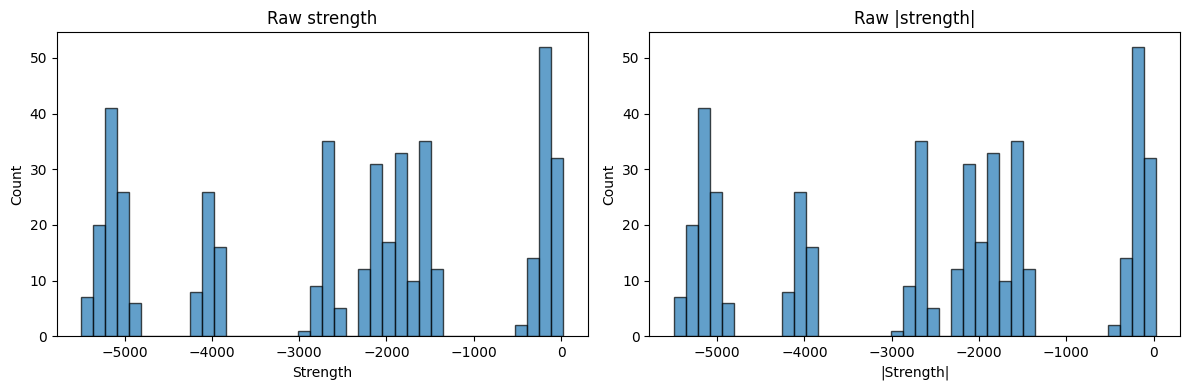

In [5]:
# Histogram of raw strength (use abs_strength for magnitude)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df["strength"], bins=40, edgecolor="black", alpha=0.7)
axes[0].set_xlabel("Strength")
axes[0].set_ylabel("Count")
axes[0].set_title("Raw strength")
axes[1].hist(df["strength"], bins=40, edgecolor="black", alpha=0.7)
axes[1].set_xlabel("|Strength|")
axes[1].set_ylabel("Count")
axes[1].set_title("Raw |strength|")
plt.tight_layout()
plt.show()

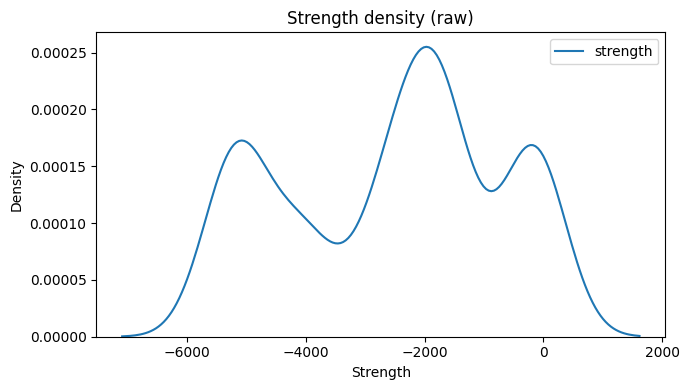

In [6]:
# Density plot (KDE); overlay by module if dual
fig, ax = plt.subplots(figsize=(7, 4))
if is_dual:
    for mod in ["front", "back"]:
        sub = df[df["module"] == mod]["strength"]
        sns.kdeplot(sub, ax=ax, label=mod)
else:
    sns.kdeplot(df["strength"], ax=ax, label="strength")
ax.set_xlabel("Strength")
ax.set_ylabel("Density")
ax.set_title("Strength density (raw)")
ax.legend()
plt.tight_layout()
plt.show()

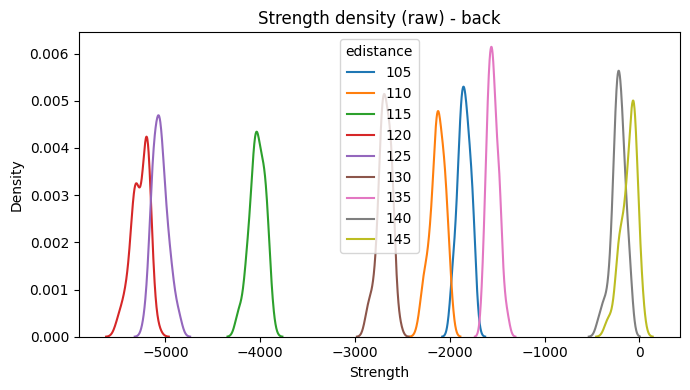

In [7]:
# One plot per module (front/back)
for mod, df_mod in df.groupby("module"):

    fig, ax = plt.subplots(figsize=(7, 4))

    for ed, sub in df_mod.groupby("edistance"):
        sns.kdeplot(
            sub["strength"],
            ax=ax,
            label=f"{ed}",
            common_norm=False
        )

    ax.set_xlabel("Strength")
    ax.set_ylabel("Density")
    ax.set_title(f"Strength density (raw) - {mod}")
    ax.legend(title="edistance")
    plt.tight_layout()
    plt.show()

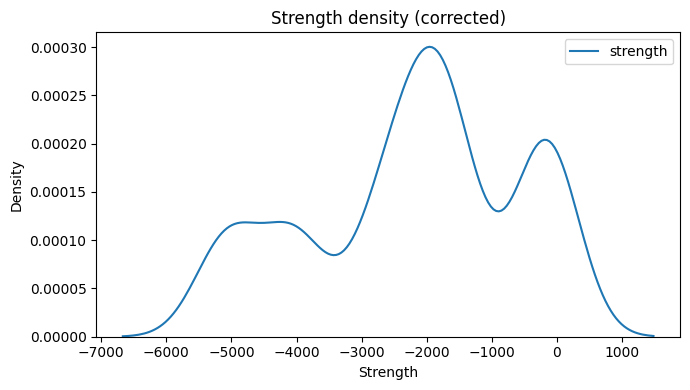

C:\Users\caden\AppData\Local\Temp\ipykernel_28948\4159382470.py:20: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.kdeplot(


TypeError: 'NoneType' object is not iterable

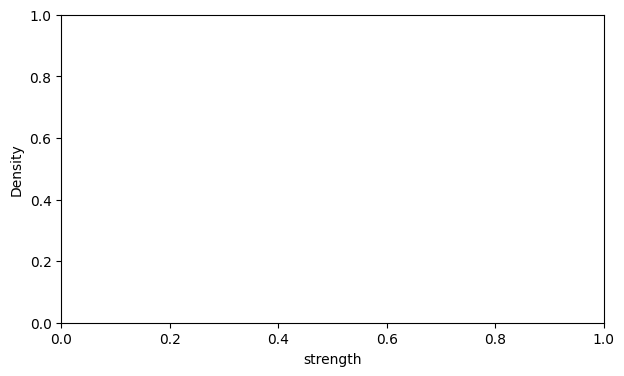

In [8]:
# Density plot based on df within edistance
df_correct = df[df["error_mm"].abs() <= 10]  # Keep only rows where error is within 10mm
# Density plot (KDE); overlay by module if dual
fig, ax = plt.subplots(figsize=(7, 4))
if is_dual:
    for mod in ["front", "back"]:
        sub = df_correct[df_correct["module"] == mod]["strength"]
        sns.kdeplot(sub, ax=ax, label=mod)
else:
    sns.kdeplot(df_correct["strength"], ax=ax, label="strength")
ax.set_xlabel("Strength")
ax.set_ylabel("Density")
ax.set_title("Strength density (corrected)")
ax.legend()
plt.tight_layout()
plt.show()

df_front = df_correct[df_correct["module"] == "front"]
fig, ax = plt.subplots(figsize=(7, 4))
sns.kdeplot(
    data=df_front,
    x="strength",
    hue="edistance",
    ax=ax,
    palette="viridis"
)
ax.set_xlabel("Strength")
ax.set_ylabel("Density")
ax.set_title("Strength density (corrected) with expected distance overlay for front")
plt.tight_layout()
plt.show()

df_back = df_correct[df_correct["module"] == "back"]
fig, ax = plt.subplots(figsize=(7, 4)) 
sns.kdeplot(
    data=df_back,
    x="strength",
    hue="edistance",
    ax=ax,
    palette="viridis"
)
ax.set_xlabel("Strength")
ax.set_ylabel("Density")
ax.set_title("Strength density (corrected) with expected distance overlay for back")
plt.tight_layout()
plt.show()

df_incorrect = df[df["error_mm"].abs() > 10]  # Keep only rows where error is greater than 10mm
# Density plot (KDE); overlay by module if dual for incorrect readings
fig, ax = plt.subplots(figsize=(7, 4))
if is_dual:
    for mod in ["front", "back"]:
        sub = df_incorrect[df_incorrect["module"] == mod]["strength"]
        sns.kdeplot(sub, ax=ax, label=mod)
else:
    sns.kdeplot(df_incorrect["strength"], ax=ax, label="strength")
ax.set_xlabel("Strength")
ax.set_ylabel("Density")
ax.set_title("Strength density for distances within error.")
ax.legend()
plt.tight_layout()
plt.show()

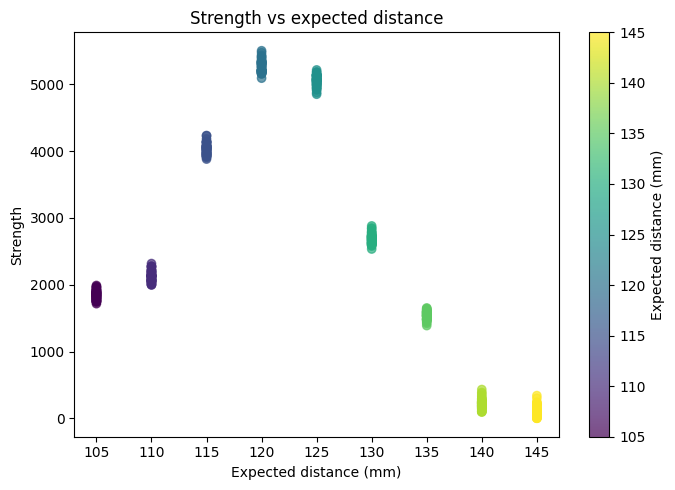

Empty DataFrame
Columns: [edistance, abs_strength]
Index: []
Empty DataFrame
Columns: [edistance, abs_strength]
Index: []
   edistance  abs_strength
0        105       1847.74
1        110       2128.40
2        115       4030.86
3        120       5265.62
4        125       5055.66
5        130       2687.20
6        135       1544.44
7        140        220.96
8        145        110.74
   edistance  abs_strength
0        105        1847.0
1        110        2126.5
2        115        4028.5
3        120        5254.5
4        125        5067.5
5        130        2686.5
6        135        1547.0
7        140         221.0
8        145          81.0


In [9]:
# Strength vs scatter plot color coded by expected distance
fig, ax = plt.subplots(figsize=(7, 5))
scatter = ax.scatter(df["edistance"], df["abs_strength"], c=df["edistance"], cmap="viridis", alpha=0.7)
ax.set_xlabel("Expected distance (mm)")
ax.set_ylabel("Strength")
ax.set_title("Strength vs expected distance")
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Expected distance (mm)")
plt.tight_layout()
plt.show()

# print avg strength per expected distance for front sensor
front_df = df[df["module"] == "front"]
avg_strength_front = front_df.groupby("edistance")["abs_strength"].mean().reset_index()
print(avg_strength_front)

# median for front
median_strength_front = front_df.groupby("edistance")["abs_strength"].median().reset_index()
print(median_strength_front)

# do same for back
back_df = df[df["module"] == "back"]
avg_strength_back = back_df.groupby("edistance")["abs_strength"].mean().reset_index()
print(avg_strength_back)

# median for back
median_strength_back = back_df.groupby("edistance")["abs_strength"].median().reset_index()
print(median_strength_back)

C:\Users\caden\AppData\Local\Temp\ipykernel_19188\3023960427.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby(trial_col, group_keys=False).apply(keep_inliers).reset_index(drop=True)


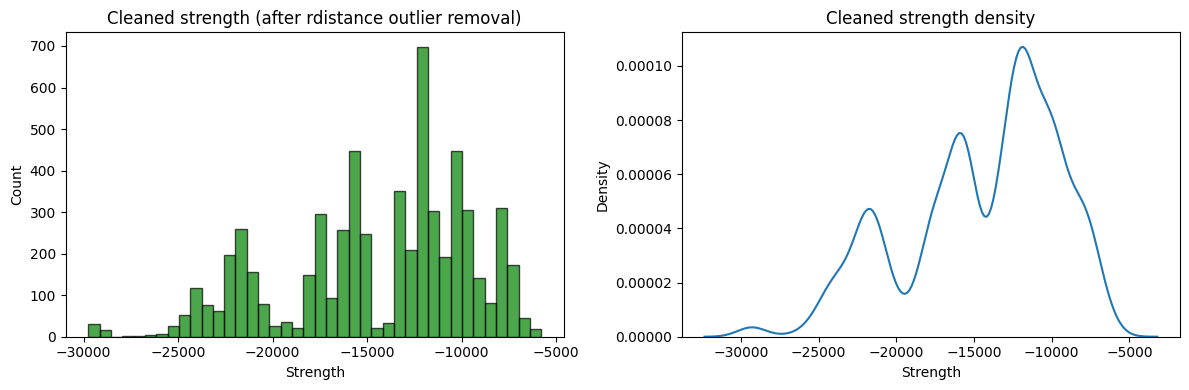

In [ ]:
# Cleaned data (remove rdistance outliers per trial), then strength distribution
df_cleaned = remove_outliers_per_trial(df, value_col="rdistance", n_std=2.0)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df_cleaned["strength"], bins=40, edgecolor="black", alpha=0.7, color="green")
axes[0].set_xlabel("Strength")
axes[0].set_ylabel("Count")
axes[0].set_title("Cleaned strength (after rdistance outlier removal)")
sns.kdeplot(df_cleaned["strength"], ax=axes[1])
axes[1].set_xlabel("Strength")
axes[1].set_ylabel("Density")
axes[1].set_title("Cleaned strength density")
plt.tight_layout()
plt.show()

## Strength by distance

In [ ]:
# Group by edistance (and trial); compute mean/median strength
stats_by_edist = (
    df_cleaned.groupby("edistance")
    .agg(
        mean_strength=("strength", "mean"),
        median_strength=("strength", "median"),
        std_strength=("strength", "std"),
        count=("strength", "size"),
    )
    .reset_index()
)
print("Strength by expected distance (cleaned):")
display(stats_by_edist)

Strength by expected distance (cleaned):


,edistance,mean_strength,median_strength,std_strength,count
0,60,-14034.274836,-12981.0,5690.448648,1983
1,70,-14812.843500,-15731.0,4614.677032,2000
2,80,-14408.145000,-12674.5,4294.033035,2000


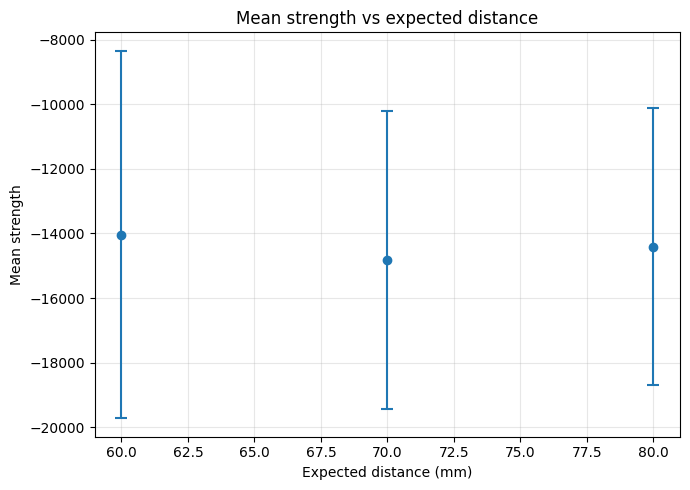

In [ ]:
# Plot: mean strength vs edistance with error bars
fig, ax = plt.subplots(figsize=(7, 5))
x = stats_by_edist["edistance"]
y = stats_by_edist["mean_strength"]
err = stats_by_edist["std_strength"].fillna(0)
ax.errorbar(x, y, yerr=err, fmt="o", capsize=4, capthick=1.5)
ax.set_xlabel("Expected distance (mm)")
ax.set_ylabel("Mean strength")
ax.set_title("Mean strength vs expected distance")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Disturbance correction (dual format: front vs back)

In [ ]:
if not is_dual:
    print("Single-sensor CSV: skipping disturbance section. Use dual format (reg 0-9 front, 10-19 back).")
else:
    # Per (trial, edistance): mean front strength and mean back strength
    front_agg = (
        df_cleaned[df_cleaned["module"] == "front"]
        .groupby(["trial", "edistance"])
        .agg(mean_strength=("strength", "mean"))
        .reset_index()
        .rename(columns={"mean_strength": "front_strength"})
    )
    back_agg = (
        df_cleaned[df_cleaned["module"] == "back"]
        .groupby(["trial", "edistance"])
        .agg(mean_strength=("strength", "mean"))
        .reset_index()
        .rename(columns={"mean_strength": "back_strength"})
    )
    diff_df = front_agg.merge(back_agg, on=["trial", "edistance"])
    diff_df["diff_strength"] = diff_df["front_strength"] - diff_df["back_strength"]
    print(f"Front-back strength difference: {len(diff_df)} (trial, edistance) pairs")
    print(diff_df[["trial", "edistance", "front_strength", "back_strength", "diff_strength"]].head(10))

Front-back strength difference: 15 (trial, edistance) pairs
   trial  edistance  front_strength  back_strength  diff_strength
0      0         60    -17270.51500  -11659.030000   -5611.485000
1      0         70    -14688.12500  -14073.865000    -614.260000
2      0         80    -16097.65000  -11427.565000   -4670.085000
3      1         60    -17491.72500   -9906.290816   -7585.434184
4      1         70    -15370.92000  -14571.500000    -799.420000
5      1         80    -14217.45000  -14446.350000     228.900000
6      2         60    -18474.19898   -9429.210000   -9044.988980
7      2         70    -14743.02500  -14769.325000      26.300000
8      2         80    -13572.67000  -15609.695000    2037.025000
9      3         60    -18641.63000   -9366.750000   -9274.880000


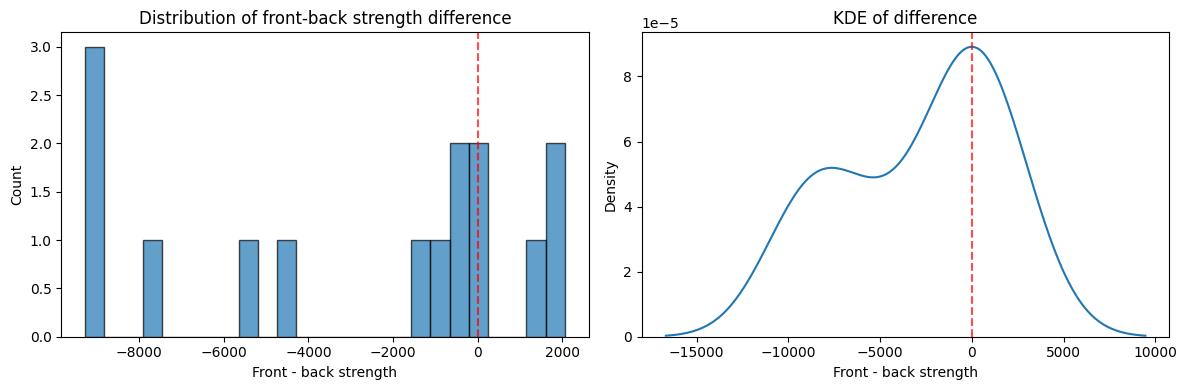

In [ ]:
if is_dual:
    # Histogram and KDE of diff_strength
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].hist(diff_df["diff_strength"], bins=25, edgecolor="black", alpha=0.7)
    axes[0].axvline(0, color="red", linestyle="--", alpha=0.7)
    axes[0].set_xlabel("Front - back strength")
    axes[0].set_ylabel("Count")
    axes[0].set_title("Distribution of front-back strength difference")
    sns.kdeplot(diff_df["diff_strength"], ax=axes[1])
    axes[1].axvline(0, color="red", linestyle="--", alpha=0.7)
    axes[1].set_xlabel("Front - back strength")
    axes[1].set_ylabel("Density")
    axes[1].set_title("KDE of difference")
    plt.tight_layout()
    plt.show()

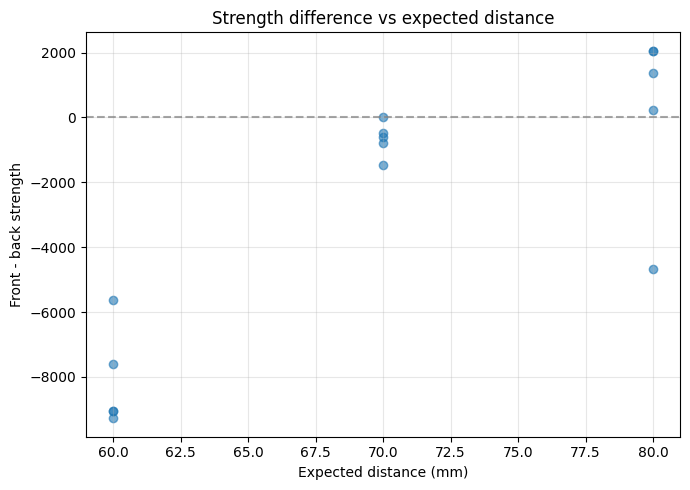

Difference summary: count      15.000000
mean    -2857.407609
std      4239.046686
min     -9274.880000
25%     -6598.459592
50%      -799.420000
75%       127.600000
max      2058.695000
Name: diff_strength, dtype: float64


In [ ]:
if is_dual:
    # Difference vs edistance
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.scatter(diff_df["edistance"], diff_df["diff_strength"], alpha=0.6)
    ax.axhline(0, color="gray", linestyle="--", alpha=0.7)
    ax.set_xlabel("Expected distance (mm)")
    ax.set_ylabel("Front - back strength")
    ax.set_title("Strength difference vs expected distance")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    # Summary stats
    print("Difference summary:", diff_df["diff_strength"].describe())

In [ ]:
if is_dual:
    # Framework: store difference; optional corrected column (extend later with distance-dependent model)
    diff_median = diff_df["diff_strength"].median()
    diff_mean = diff_df["diff_strength"].mean()
    diff_df["corrected_back_strength"] = diff_df["back_strength"] + diff_median
    print(f"Median(diff) = {diff_median:.1f}, mean(diff) = {diff_mean:.1f}")
    print("Corrected back strength = back_strength + median(diff). For distance-dependent correction, fit diff ~ edistance.")

Median(diff) = -799.4, mean(diff) = -2857.4
Corrected back strength = back_strength + median(diff). For distance-dependent correction, fit diff ~ edistance.


---
To use a different CSV, set `STRENGTH_CSV` in the second cell and run all cells.